In this notebook, I build a complete machine learning pipeline for fetal state classification using the CTG dataset. The workflow includes data loading, preprocessing, exploratory data analysis, model training, evaluation, optimization, and model saving.

3.1 Load Data and Import Libraries

In [573]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import json
import joblib as j
import streamlit as st
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("joblib:", j.__version__)
print("streamlit:", st.__version__)

numpy: 1.24.4
pandas: 2.0.3
joblib: 1.4.2
streamlit: 1.40.1


In [574]:
df = pd.read_excel("/Users/iramishtiaq/Documents/GitHub/ml-project/CTG.xls", sheet_name="Raw Data", skiprows=0)
df = df.dropna(axis=1, how='all')  # remove empty columns
df = df.dropna()
df = df.select_dtypes(include=['number'])
print(df.shape)
print(df.head)


(2126, 37)
<bound method NDFrame.head of            b       e    LBE     LB   AC   FM   UC  ASTV  MSTV  ALTV  ...    C  \
1      240.0   357.0  120.0  120.0  0.0  0.0  0.0  73.0   0.5  43.0  ...  0.0   
2        5.0   632.0  132.0  132.0  4.0  0.0  4.0  17.0   2.1   0.0  ...  0.0   
3      177.0   779.0  133.0  133.0  2.0  0.0  5.0  16.0   2.1   0.0  ...  0.0   
4      411.0  1192.0  134.0  134.0  2.0  0.0  6.0  16.0   2.4   0.0  ...  0.0   
5      533.0  1147.0  132.0  132.0  4.0  0.0  5.0  16.0   2.4   0.0  ...  0.0   
...      ...     ...    ...    ...  ...  ...  ...   ...   ...   ...  ...  ...   
2122  2059.0  2867.0  140.0  140.0  0.0  0.0  6.0  79.0   0.2  25.0  ...  0.0   
2123  1576.0  2867.0  140.0  140.0  1.0  0.0  9.0  78.0   0.4  22.0  ...  0.0   
2124  1576.0  2596.0  140.0  140.0  1.0  0.0  7.0  79.0   0.4  20.0  ...  0.0   
2125  1576.0  3049.0  140.0  140.0  1.0  0.0  9.0  78.0   0.4  27.0  ...  0.0   
2126  2796.0  3415.0  142.0  142.0  1.0  1.0  5.0  74.0   0.4  36.0 

3.2 Data Preprocessing, Exploratory Data Analysis (EDA), and Train-Test Split

In [575]:
print(df.isnull().sum())

b           0
e           0
LBE         0
LB          0
AC          0
FM          0
UC          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
DL          0
DS          0
DP          0
DR          0
Width       0
Min         0
Max         0
Nmax        0
Nzeros      0
Mode        0
Mean        0
Median      0
Variance    0
Tendency    0
A           0
B           0
C           0
D           0
E           0
AD          0
DE          0
LD          0
FS          0
SUSP        0
CLASS       0
NSP         0
dtype: int64


Missing values were checked and removed during preprocessing. The dataset contains no null values after cleaning, ensuring data quality for model training.

Feature Scaling

In [576]:


from sklearn.preprocessing import StandardScaler

X = df.drop("NSP", axis=1)
y = df["NSP"]
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

Feature scaling was applied to normalize the range of input features. This is particularly important for distance-based models such as KNN and optimization-based models like Logistic Regression.

EXPLORATORY DATA ANALYSIS (EDA)

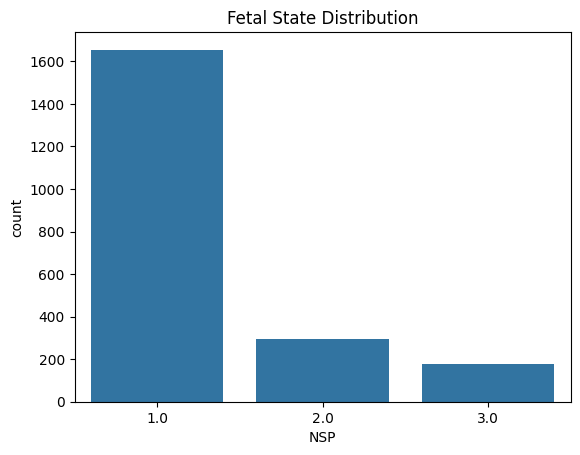

In [577]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title("Fetal State Distribution")
plt.show()

The dataset is imbalanced, with a higher number of normal cases compared to suspect and pathologic cases. This imbalance may affect model performance.

Feature Distribution

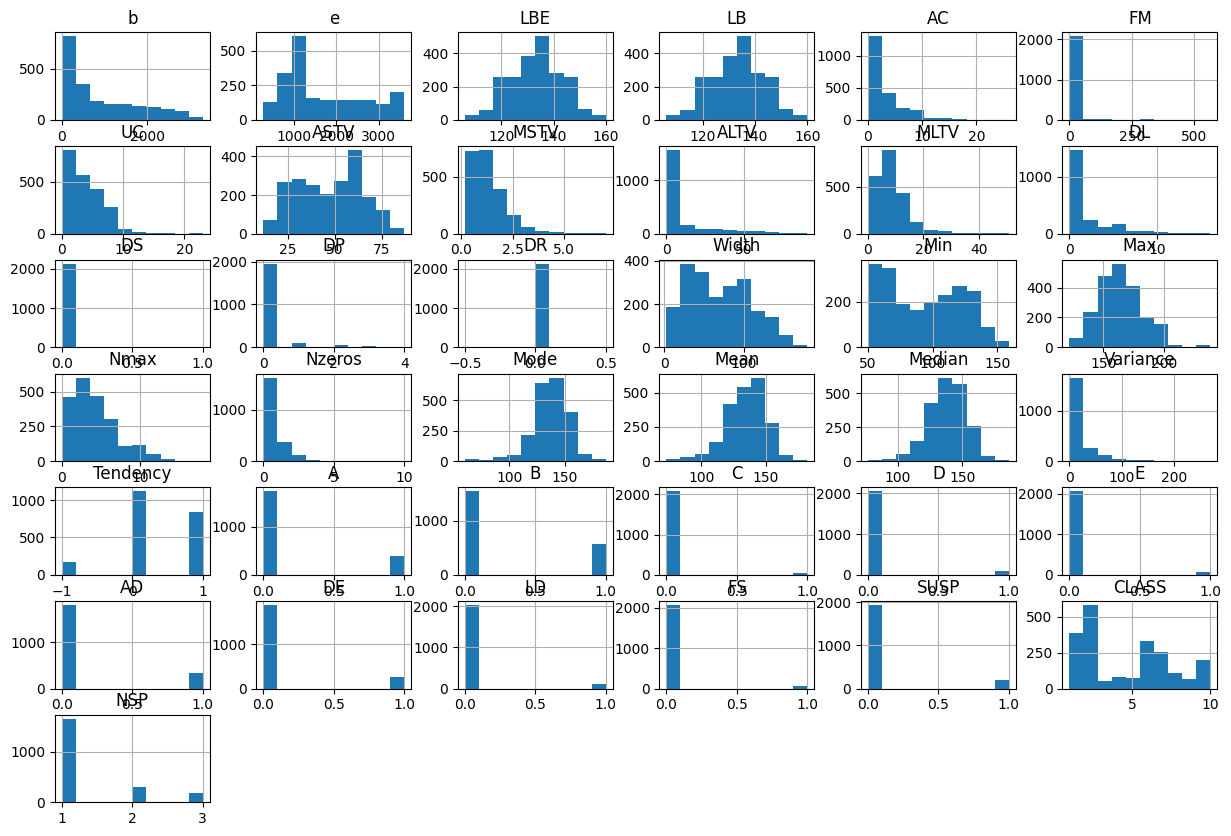

In [578]:
df.hist(figsize=(15,10))
plt.show()

The features show varying distributions, including skewness in some variables. This reinforces the need for scaling and careful model selection.

Correlation Heatmap

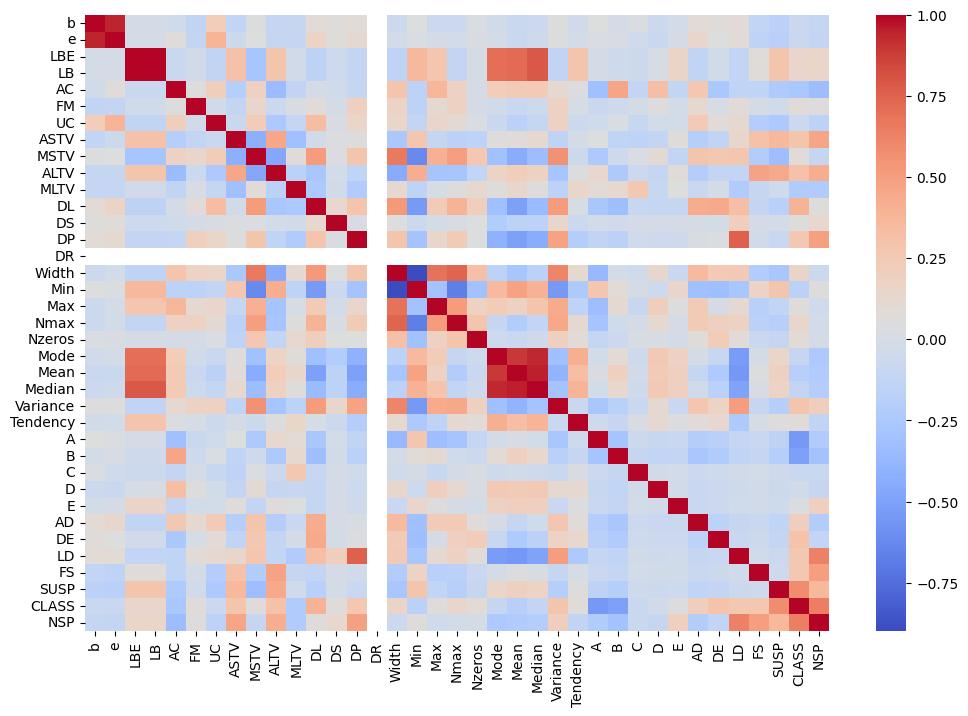

In [579]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

Several features are highly correlated, indicating multicollinearity. This may introduce redundancy and impact certain models, particularly linear ones.

In [580]:
# temp commented
'''corr_matrix = df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]'''

'corr_matrix = df.corr().abs()\n\nupper = corr_matrix.where(\n    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)\n)\n\nto_drop = [column for column in upper.columns if any(upper[column] > 0.9)]'

Highly correlated features (correlation > 0.9) were removed to reduce redundancy and improve model stability.

In [581]:
#Outlier detection
'''plt.figure(figsize=(15,6))
sns.boxplot(df_reduced.drop("NSP", axis=1))
plt.xticks(rotation=90)
plt.show()'''

'plt.figure(figsize=(15,6))\nsns.boxplot(df_reduced.drop("NSP", axis=1))\nplt.xticks(rotation=90)\nplt.show()'

Outliers were identified but not removed to retain full dataset variability.

 TRAIN-TEST SPLIT

In [582]:

X = df.drop("NSP", axis=1)
y = df["NSP"]
print(y)

1       2.0
2       1.0
3       1.0
4       1.0
5       1.0
       ... 
2122    2.0
2123    2.0
2124    2.0
2125    2.0
2126    1.0
Name: NSP, Length: 2126, dtype: float64


In [583]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
j.dump(X_test.iloc[0].to_dict(), "sample_input.pkl")

['sample_input.pkl']

The dataset was cleaned, scaled, and analyzed through EDA. The data was then split into training and testing sets using stratified sampling to ensure balanced class representation.

3.3 Model Training

In [584]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "KNN": KNeighborsClassifier()
}


In [585]:
print("y_train distribution:\n", y_train.value_counts())
print("y_test distribution:\n", y_test.value_counts())

y_train distribution:
 NSP
1.0    1323
2.0     236
3.0     141
Name: count, dtype: int64
y_test distribution:
 NSP
1.0    332
2.0     59
3.0     35
Name: count, dtype: int64


Three models were selected to represent different machine learning approaches. Logistic Regression is a linear model, Decision Tree is a rule-based model, and KNN is a distance-based model. This allows comparison of different learning strategies on the same dataset.

Train Base Models

In [586]:
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

Each model was trained using default parameters (base models). This provides a baseline for comparison before applying any optimization techniques.

Training Accuracy

In [587]:
for name, model in trained_models.items():
    train_acc = model.score(X_train, y_train)
    print(f"{name} Training Accuracy: {train_acc:.4f}")
 

Logistic Regression Training Accuracy: 0.9935
Decision Tree Training Accuracy: 1.0000
KNN Training Accuracy: 0.9912


3.4 Model Evaluation

In [588]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import json

results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    
    report = classification_report(y_test, y_pred)
    print(report)

    results[name] = classification_report(y_test, y_pred, output_dict=True)


Logistic Regression
Accuracy: 0.9859154929577465
              precision    recall  f1-score   support

         1.0       0.99      1.00      0.99       332
         2.0       0.98      0.92      0.95        59
         3.0       1.00      1.00      1.00        35

    accuracy                           0.99       426
   macro avg       0.99      0.97      0.98       426
weighted avg       0.99      0.99      0.99       426


Decision Tree
Accuracy: 0.9765258215962441
              precision    recall  f1-score   support

         1.0       0.98      0.99      0.99       332
         2.0       0.95      0.88      0.91        59
         3.0       1.00      1.00      1.00        35

    accuracy                           0.98       426
   macro avg       0.97      0.96      0.97       426
weighted avg       0.98      0.98      0.98       426


KNN
Accuracy: 0.9835680751173709
              precision    recall  f1-score   support

         1.0       0.98      1.00      0.99       332
 

In [589]:
with open("classification_report.json", "w") as f:
    json.dump(results, f, indent=4)

Model performance was evaluated using accuracy, precision, recall, and F1-score. These metrics provide a comprehensive understanding of classification performance across all classes.

Confusion Matrix

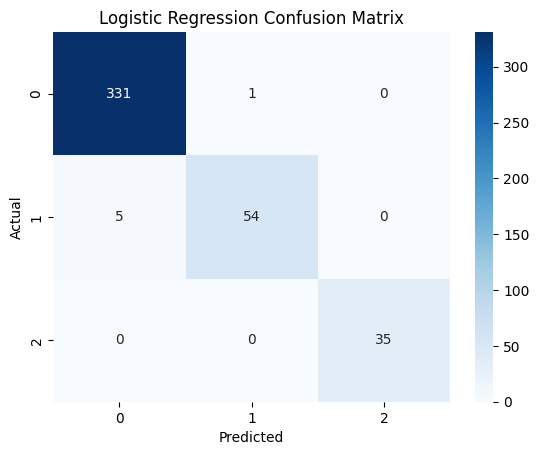

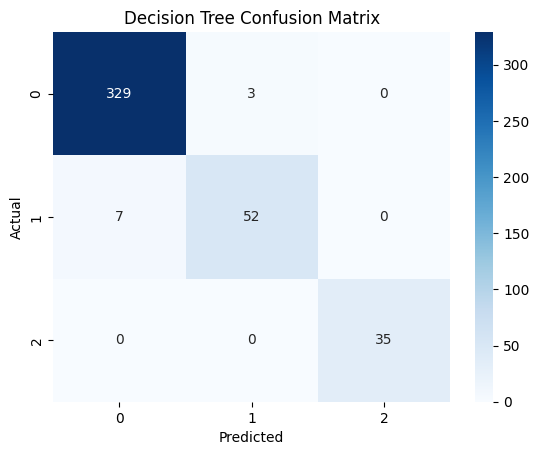

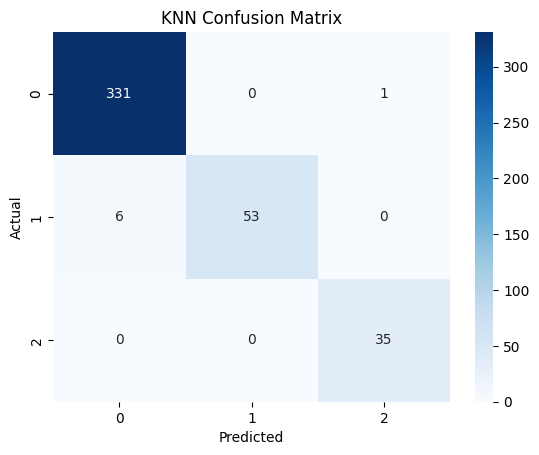

In [590]:
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

The confusion matrix shows how well the model distinguishes between classes. Misclassifications are more frequent in minority classes, highlighting the impact of class imbalance.

K-Fold Cross Validation

In [591]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{name} K-Fold CV Accuracy: {scores.mean():.4f}")

Logistic Regression K-Fold CV Accuracy: 0.9882
Decision Tree K-Fold CV Accuracy: 0.9818
KNN K-Fold CV Accuracy: 0.9888


Stratified K-Fold

In [592]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5)

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=skf)
    print(f"{name} Stratified CV Accuracy: {scores.mean():.4f}")

Logistic Regression Stratified CV Accuracy: 0.9882
Decision Tree Stratified CV Accuracy: 0.9818
KNN Stratified CV Accuracy: 0.9888


3.5 Testing on New Instances

In [593]:
sample = X_test[:30]
predictions = trained_models["Decision Tree"].predict(sample)

print("Predictions:", predictions)
print("Actual:", y_test.iloc[:30].values)

Predictions: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 2. 1.
 1. 1. 1. 1. 1. 2.]
Actual: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 1. 1.
 1. 1. 1. 1. 1. 2.]


In [602]:
sample = X_test.iloc[[0]]

pred = best_model.predict(sample)
actual = y_test.iloc[0]

print("Predicted:", pred[0])
print("Actual:", actual)

print("Probabilities:", best_model.predict_proba(sample)[0])

Predicted: 1.0
Actual: 1.0
Probabilities: [1. 0. 0.]


3.6 Model Optimization: Hyperparameter Tuning

In [594]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5, 7],               # ❗ remove None (prevents overfitting)
    "min_samples_split": [5, 10],         # ❗ avoid tiny splits
    "min_samples_leaf": [2, 5],           # ❗ avoid tiny leaves
    "criterion": ["gini", "entropy"],
    "class_weight": ["balanced"]          # ❗ force handling imbalance
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)

Best Params: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5}


3.7 Model Serialization

In [595]:


j.dump(best_model, "decision_tree_best_model.pkl")
j.dump(scaler, "scaler.pkl")
j.dump(X.columns.tolist(), "feature_names.pkl")
j.dump(X.mean().to_dict(), "feature_means.pkl")
loaded_model = j.load("decision_tree_best_model.pkl")


The model was successfully trained, evaluated, optimized, and serialized. The saved model can now be reused for future predictions without retraining, making it suitable for deployment in real-world applications.